## 1. Configuración

---


### Instalación de las librerias unthermal y unmotor

Ejecute los siguientes comandos en la terminal (bash) de visual studio code para reinstalar las librerias del motor y del sistema térmico. __Asegúrese de instalar  [Git](https://git-scm.com/download/win/ "Git").__

`pip install --ignore-installed  git+https://github.com/nebisman/UNThermal.git@main#subdirectory=code/python_code`

`pip install --ignore-installed  git+https://github.com/nebisman/UNDCMotor.git@main#subdirectory=code/python_code`


Si la instalación reporta algún error de permisos del sistema operativo, use esta opción:


`pip install --ignore-installed --user git+https://github.com/nebisman/UNThermal.git@main#subdirectory=code/python_code`

`pip install --ignore-installed --user git+https://github.com/nebisman/UNDCMotor.git@main#subdirectory=code/python_code`


### Importación de comandos de la libreria unthermal y unmotor

A continuación importamos los comandos básicos que usaremos de la libreria `unthermal` y `unmotor` y la libreria `Matplotlib` para las figuras. 

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import unthermal as temp
import unmotor as motor


### Ayuda de las funciones del software

Aqui está  [la ayuda de las funciones de software](https://nebisman.github.io/UNThermal/index.html)


### Definición de los sistemas en el IoT

Lo primero que necesitamos es definir tanto el sistema térmico como el motor como sistemas  IoT.

In [4]:
mi_motor = motor.MotorSystemIoT(plant_number = "PC-M-02" , broker_address = "192.168.1.100", port=1883) 

## Sintonía por métodos algebraicos de un controlador PI para el motor

El Motor DC puede ser descrito aproximadamente por  [la siguiente función de transferencia de primer orden](https://github.com/nebisman/UNDCMotor/blob/main/docs/modelo_matematico_unmotor.pdf):

$$G_1(s)= \frac{\alpha}{\tau\, s + 1}.$$



#### Obtención del modelo del motor.
+ Encuentre los modelos del motor DC que está usando mediante la función `get_fomodel_step` para la velocidad de operación de $y_{OP}=360^o/s$.  

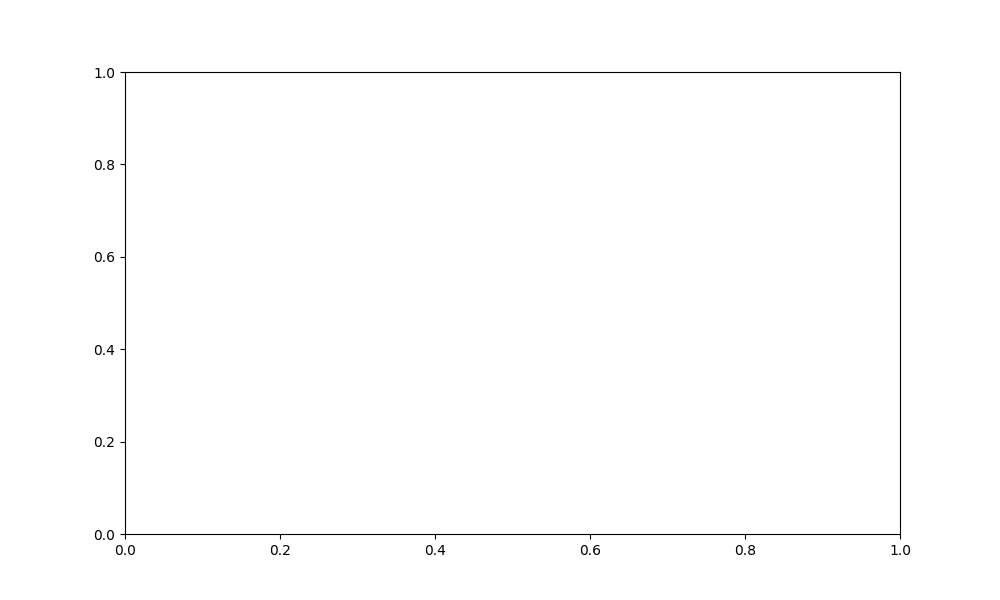

Connected successfully to MQTT Broker!
Subscribed:  1   (2,)


KeyboardInterrupt: 

In [5]:
motor.get_static_model(mi_motor)
alfa, tau = motor.get_fomodel_step(mi_motor, yop = 360)


# Especificaciones (todos los diseños)
tee_m = [0.6, 0.6]
tr_m = [0.4, 0.4]
sp_m = [0.1, 0.05]

# Listas de resultados
zeta_m = []
wn_m = []
kp_m = []
ki_m = []

# Cálculo para cada diseño
for i in range(len(tee_m)):
    tee = tee_m[i]
    sp = sp_m[i]

    zeta = -np.log(sp) / np.sqrt(np.log(sp)**2 + np.pi**2)
    wn = (tee * zeta) / 5
    kp = (2 * tau * zeta * wn - 1) / alfa
    ki = (tau * wn**2) / alfa

    zeta_m.append(zeta)
    wn_m.append(wn)
    kp_m.append(kp)
    ki_m.append(ki)

# Resultados
print("zeta:", zeta_m)
print("wn:", wn_m)
print("kp:", kp_m)
print("ki:", ki_m)

### Sintonía algebraica de PI para el motor

Antes de comenzar esta guia, revise cuidadosamente y comprenda el [material sobre sintonía algebraica de un  PI para un sistema de primer orden de este documento.](https://drive.google.com/file/d/1gUnwypS_lvpQAX4MQpw9NazFORTOkXdA/view?usp=sharing).

Una vez realizada esta revisión realice el siguiente trabajo experimental.


#### Experimento de sintonización de controladores

1. Use el método de sintonía algebraica descrito en el documento para obtener controladores PI de la velocidad angular del motor,  de acuerdo con la siguiente tabla de especificaciones:

| Controlador | $t_{ee}$ (tiempo de establecimiento) | $t_r$ (tiempo de subida) | $SP$ (sobrepico) |
|-------------|-----------|-------|------|
| PI-VEL-1        | $\leq\, 1.0 s$     | $\leq\, 0.5 s$ | $\approx 10\%$  |
| PI-VEL-2        | $\leq\, 1.0 s$     | $\leq\, 0.5 s$ | $\approx 5\%$  |





#### Notas importantes:

1. El modelo usado para estos diseños es el modelo de primer orden obtenido con la función `get_fomodel_step` en el punto de operación de $360^o$.

2. Para el motor DC puede asumir que el tiempo de retraso no modelado es la mitad del tiempo de muestreo del controlador digital que es de $20\,ms$, esto es: 

$$T_{nm}=0.01\,s$$

3. Se tiene también  la restricción de tensión que debemos (y podemos) aplicar al motor, dada por 
$$
|u(t)| \leq 5\,V
$$ 

4. Haga las iteraciones manualmente siguiendo el método. Puede hacer los pasos 1-2 en una celda y en otra celda hacer los pasos 3-8, cambiando convenientemente los parámetros de diseño $\omega_n$ y $\zeta$. 

5. Use un cambio en la referencia de $0$ a $360^o/s$


6. Para todos los experimentos use la función `set_pid()` parametrizada con `beta=0` (para un PI de dos GDL) y con `output=speed` para el control de velocidad, como en el siguiente ejemplo. Puede usar la función `draw_specifications`, dada a continuación, para revisar los requerimientos de diseño. No tiene que definirla sino una vez.

In [ ]:
def draw_specifications(tee, tr, SP):
    import mplcursors
    fig = plt.gcf()
    ay, au = fig.get_axes()
    delta_r = r1 - r0

    # tee
    ay.axvline(tee + t0, color='#0080668F', linestyle='--', linewidth=1.25)
    ay.text(t0 + tee + t1/50, r0 + 0.1*delta_r, "$t_{ee}$", fontsize=14)

    # tr
    ay.plot([t0, t0 + tr, t0 + tr],
            [r0 + 0.9*delta_r, r0 + 0.9*delta_r, r0 - 0.1*delta_r],
            color='#917c6fff', linestyle='--', linewidth=1.25)
    ay.text(t0 + tr + t1/50, r0 + 0.1*delta_r, "$t_r$", fontsize=14)

    # SP (CORREGIDO)
    ay.axhline(r1 + SP * delta_r, color='#d42affff', linestyle='--', linewidth=1.25)
    ay.text(0.8 * t0, r1 + (SP + 0.025) * delta_r, "$SP$", fontsize=14)

    mplcursors.cursor(ay.lines)
    return ay, au



# programacion del PI y respuesta al escalón 
t0 = 0.5
t1 = 2
r0 = 0
r1 = 360

# juego de comandos para programar el PI
motor.set_reference(mi_motor,0) # pongo la velocidad en 0 antes de iniciar
for i in range(len(tee_m)):
    
    kp = kp_m[i]
    ki = ki_m[i]
    tee = tee_m[i]
    tr = tr_m[i] 
    sp = sp_m[i]

    motor.set_reference(mi_motor, 0)

    motor.set_pid(mi_motor, kp=kp, ki=ki, kd=0, beta=0, output="speed")

    t, r, y, u = motor.step_closed(mi_motor, r0=r0, r1=r1, t0=t0, t1=t1)

    draw_specifications(tee, tr, sp)

    motor.set_reference(mi_motor, 0)

#### Preguntas orientadoras

+ Al final de esta parte, además de los gráficos experimentales, presente  y en una tabla  la siguiente información. Note que picando en la gráfica aparece el valor. 

| Controlador | $\zeta$ (final) | $\omega_n$ (final) |  $t_{ee}$ (real) | $t_r$ (real) | $SP$ (real) |

+ ¿Cual de estos controladores tiene la mejor respuesta a perturbaciones constantes, según  los resultados de la tabla ya la teoría vista en clase? 
+ Pruebe el controlador con la perilla para varias velocidades. Discuta si funciona como se espera para las pruebas realizadas.

### Sintonía algebraica de PI para el sistema térmico

Los principios generales son los mismos que usó en el motor DC  y que están en la guia [material sobre sintonía algebraica de un  PI para un sistema de primer orden.](https://github.com/nebisman/UNThermal/blob/main/docs/metodo_sintonia_algebraico_PI_PID.pdf).

#### Experimentos

 Use el método de sintonía algebraica descrito en el documento para obtener 3 controladores PI del sistema térmico,  de acuerdo con la siguiente tabla de especificaciones:

| Controlador | $t_{ee}$ (tiempo de establecimiento) | $t_r$ (tiempo de subida) | $SP$ (sobrepico) |
|-------------|-----------|-------|------|
| PI-TEMP-1        | $\leq\, 40\, s$     | $\leq\,20\, s$ | $=10\%$  |
| PI-TEMP-2        | $\leq\,40\, s$     | $\leq\,20\, s$ | $=0\%$  |
| PI-TEMP-3        | $\leq\,1\, s$     | $\leq\,0.5 s$ | $=10\%$  |




#### Notas importantes:

1. Use como modelo uno de los obtenidos en la primera práctica. El que su concepto tuvo el mejor ajuste a los datos. 



2. Note que para el sistema térmico, se puede asumir que el tiempo de retraso no modelado, es la mitad del  tiempo de muestreo del controlador digital que es $0.8s$, esto es: 

$$T_{nm}=0.4\,s$$

3. Se tiene también  la restricción de señal de control que podemos aplicar al sistema térmico es el porcentaje de potencia: 
$$
|u(t)| \leq 100\% 
$$ 

4. Haga las iteraciones manualmente siguiendo el método. Puede hacer los pasos 1-2 en una celda y en otra celda hacer los pasos 3-8, cambiando convenientemente los parámetros de diseño $\omega_n$ y $\zeta$. 


5. Use un cambio en la referencia de $60^o$ a $70^o$.  

6. Para todos los experimentos use la función `set_pid()` parametrizada con `beta=0` (para un PI de dos GDL), como en el siguiente ejemplo y puede usar la función `draw_specifications` para revisar los requerimientos de diseño. 


In [ ]:
# definicion del sistema termico
mi_termico = temp.ThermalSystemIoT(plant_number = "PC-T-XX" , broker_address = "192.168.1.100", port=1883)

In [ ]:
# =========================
# 1. Especificaciones
# =========================
tee_th = [30, 30, 0.4]
tr_th  = [15, 15, 0.4]
sp_th  = [0.1, 0.001, 0.1]   # en decimal (10%, 0.1%, etc.)

# =========================
# 2. Listas de resultados
# =========================
zeta_th = []
wn_th   = []
kp_th   = []
ki_th   = []

# =========================
# 3. Modelo del sistema
# =========================
alfa_th, tau_th = temp.get_fomodel_step(mi_termico, yop=AAAA)

# =========================
# 4. Cálculo de controladores
# =========================
for i in range(len(tee_th)):

    tee = tee_th[i]
    sp  = sp_th[i]

    zeta = -np.log(sp) / np.sqrt(np.log(sp)**2 + np.pi**2)
    wn   = (tee * zeta) / 5

    kp = (2 * tau_th * zeta * wn - 1) / alfa_th
    ki = (tau_th * wn**2) / alfa_th

    zeta_th.append(zeta)
    wn_th.append(wn)
    kp_th.append(kp)
    ki_th.append(ki)

# =========================
# 5. Parámetros de simulación
# =========================
t0 = 70
t1 = 70
r0 = 60
r1 = 70

# =========================
# 6. Función de especificaciones
# =========================
def draw_specifications(tee, tr, SP):
    import mplcursors

    fig = plt.gcf()
    ay, au = fig.get_axes()
    delta_r = r1 - r0

    # tee
    ay.axvline(tee + t0, linestyle='--', linewidth=1.25)
    ay.text(t0 + tee + t1/50, r0 + 0.1*delta_r, "$t_{ee}$")

    # tr
    ay.plot([t0, t0 + tr, t0 + tr],
            [r0 + 0.9*delta_r, r0 + 0.9*delta_r, r0 - 0.1*delta_r],
            linestyle='--', linewidth=1.25)
    ay.text(t0 + tr + t1/50, r0 + 0.1*delta_r, "$t_r$")

    # sobrepico
    ay.axhline(r1 + SP * delta_r, linestyle='--', linewidth=1.25)
    ay.text(0.8 * t0, r1 + (SP + 0.025) * delta_r, "$SP$")

    mplcursors.cursor(ay.lines)

    return ay, au

# =========================
# 7. Simulación automática
# =========================
t_th = []
y_th = []

for i in range(len(tee_th)):

    kp = kp_th[i]
    ki = ki_th[i]
    tee = tee_th[i]
    tr  = tr_th[i]
    sp  = sp_th[i]

    # Inicializar referencia
    temp.set_reference(mi_termico, r0)

    # Configurar PI
    temp.set_pid(mi_termico, kp=kp, ki=ki, kd=0, beta=0)

    # Simulación
    t, r, y, u = temp.step_closed(mi_termico, r0=r0, r1=r1, t0=t0, t1=t1)

    # Guardar resultados
    t_th.append(t)
    y_th.append(y)

    # Dibujar especificaciones
    draw_specifications(tee, tr, sp)

plt.figure()

for i in range(len(t_th)):
    plt.plot(t_th[i], y_th[i], label=f'Diseño {i+1}')

plt.xlabel("Tiempo")
plt.ylabel("Salida")
plt.title("Comparación de diseños PI - Sistema térmico")
plt.legend()
plt.grid()

plt.show()

#### Preguntas orientadoras

+ Al final de esta parte, además de los gráficos experimentales, presente una tabla con la siguiente información. 

| Controlador | $\zeta$ (final) | $\omega_n$ (final) |  $t_{ee}$ (real) | $t_r$ (real) | $SP$ (real) |

+ ¿Cual de estos controladores tiene la mejor respuesta a perturbaciones, según la teoría y los resultados de la tabla anterior ?
+ Compruebe la respuesta a perturbaciones del sistema con un ventilador. 

## Control PID del ángulo del motor DC

___

Revise cuidadosamente y comprenda el  [material sobre sintonía algebraica de un  PID para control de ángulo en un motor DC de este documento.](https://github.com/nebisman/UNThermal/blob/main/docs/metodo_sintonia_algebraico_PI_PID.pdf) Una vez realizada esta revisión, realice el siguiente trabajo experimental.


### Experimentos


1. Use la función `get_fomodel_step(mi_motor, yop =100)`, en el punto de operación $y_{OP}=100^o/s$.

2.  Use el método de sintonía algebraica descrito en el [documento](https://github.com/nebisman/UNThermal/blob/main/docs/metodo_sintonia_algebraico_PI_PID.pdf) para obtener 2 controladores PID para el control del ángulo $\theta$ del motor,  de acuerdo con la siguiente tabla de especificaciones:

| Controlador | $t_{ee}$ (tiempo de establecimiento) | $t_r$ (tiempo de subida) | $SP$ (sobrepico) |
|-------------|-----------|-------|------|
| PID-ANGULO-2        | $\leq\,1.5 s$     | $\leq\,0.8 s$ | $=10\%$  |
| PID-ANGULO-3        | $\leq\,1.5 s$     | $\leq\,0.8 s$ | $=5\%$  |




#### Notas importantes:

1. El modelo usado para estos diseños es el modelo de primer orden ontenido con la función `get_models_prbs(.)` a una velocidad de $100^o/s$ multiplicado por un integrador. ¿Por qué?

2. Note que para el motor DC puede asumir que el tiempo de retraso no modelado, es el tiempo de muestreo del controlador digital, esto es: 

$$T_{nm}=0.01\,s$$

3. Se tiene también  la restricción de tensión que debemos (y podemos) aplicar al motor, dada por 
$$
|u(t)| \leq 5\,V
$$ 

4. Haga las iteraciones siguiendo el método, para ganar una comprensión intuitiva. Puede hacer los pasos 1-2 en una celda y en otra celda hacer los pasos 3-9, cambiando convenientemente los parámetros de diseño $\omega_n$ y $\zeta$. 

5. Use un cambio en la referencia de $0$ a $90^o$. Verifique visualmente que si se reaiza este cambio. 


6. Para todos los experimentos use la función `set_pid()` parametrizada con `beta=0` (para un PID de dos GDL) y con `output=angle` para control de ángulo, como en el siguiente ejemplo. Puede usar la función `draw_specifications` para revisar los requerimientos de diseño. 

In [ ]:
# =========================
# 1. Especificaciones
# =========================
tee_pid = [1, 1]
tr_pid  = [0.6, 0.6]
sp_pid  = [0.1, 0.05]   # en decimal

n_pid = 10   # parámetro del PID

# =========================
# 2. Listas de resultados
# =========================
zeta_pid = []
wn_pid   = []
kp_pid   = []
ki_pid   = []
kd_pid   = []

# =========================
# 3. Modelo del sistema
# =========================
alfa_pid, tau_pid = motor.get_fomodel_step(mi_motor, yop=100)

# ⚠️ IMPORTANTE: alfa NO puede ser 0
if alfa_pid == 0:
    raise ValueError("alfa no puede ser 0 para el diseño del PID")

# =========================
# 4. Cálculo del PID
# =========================
for i in range(len(tee_pid)):

    tee = tee_pid[i]
    sp  = sp_pid[i]

    zeta = -np.log(sp) / np.sqrt(np.log(sp)**2 + np.pi**2)
    wn   = (tee * zeta) / 5

    kp = (tau_pid * (wn**2) * (2 * zeta * n_pid + 1)) / alfa_pid
    ki = (n_pid * tau_pid * (wn**3)) / alfa_pid
    kd = (tau_pid * wn * (2 * zeta + n_pid) - 1) / alfa_pid

    zeta_pid.append(zeta)
    wn_pid.append(wn)
    kp_pid.append(kp)
    ki_pid.append(ki)
    kd_pid.append(kd)

# =========================
# 5. Parámetros simulación
# =========================
t0 = 0.5
t1 = 2
r0 = 0
r1 = 100

# =========================
# 6. Función de especificaciones
# =========================
def draw_specifications(tee, tr, SP):
    import mplcursors

    fig = plt.gcf()
    ay, au = fig.get_axes()
    delta_r = r1 - r0

    ay.axvline(tee + t0, linestyle='--', linewidth=1.25)
    ay.text(t0 + tee + t1/50, r0 + 0.1*delta_r, "$t_{ee}$")

    ay.plot([t0, t0 + tr, t0 + tr],
            [r0 + 0.9*delta_r, r0 + 0.9*delta_r, r0 - 0.1*delta_r],
            linestyle='--', linewidth=1.25)
    ay.text(t0 + tr + t1/50, r0 + 0.1*delta_r, "$t_r$")

    ay.axhline(r1 + SP * delta_r, linestyle='--', linewidth=1.25)
    ay.text(0.8 * t0, r1 + (SP + 0.025) * delta_r, "$SP$")

    mplcursors.cursor(ay.lines)

    return ay, au

# =========================
# 7. Simulación automática
# =========================
t_pid = []
y_pid = []

for i in range(len(tee_pid)):

    kp = kp_pid[i]
    ki = ki_pid[i]
    kd = kd_pid[i]
    tee = tee_pid[i]
    tr  = tr_pid[i]
    sp  = sp_pid[i]

    motor.set_reference(mi_motor, 0)

    motor.set_pid(mi_motor,
                  kp=kp,
                  ki=ki,
                  kd=kd,
                  beta=0,
                  output="angle",
                  deadzone=0)

    t, r, y, u = motor.step_closed(mi_motor,
                                   r0=r0,
                                   r1=r1,
                                   t0=t0,
                                   t1=t1)

    t_pid.append(t)
    y_pid.append(y)

    draw_specifications(tee, tr, sp)

# =========================
# 8. Comparación de diseños
# =========================
plt.figure()

for i in range(len(t_pid)):
    plt.plot(t_pid[i], y_pid[i], label=f'Diseño {i+1}')

plt.xlabel("Tiempo")
plt.ylabel("Ángulo")
plt.title("Comparación de diseños PID - Motor")
plt.legend()
plt.grid()

plt.show()

#### Preguntas orientadoras


+ Al final de esta parte, además de los gráficos experimentales, presente una tabla con la siguiente información. 

| Controlador | $\zeta$ (final) | $\omega_n$ (final) |  $t_{ee}$ (real) | $t_r$ (real) | $SP$ (real) | 

+ ¿Cuál de estos controladores tiene la mejor respuesta a perturbaciones, según la teoría y los resultados de la tabla ?


### Experimento con $\zeta<0$


+ Para el controlador PID-ANGULO-2 cambie el valor de $\zeta$ por $-\zeta$ y calcule las constantes del PID. Programe el PID y obtenga la respuesta al escalón.

#### Pregunta orientadora

Observe y explique el fenómeno del experimento anterior. 




